# Projet final — Timing de la volatilité réalisée pour une stratégie de carry sur volatilité

Ce notebook présente notre projet final de **Volatility Trading**, consacré au **timing de la volatilité réalisée** dans le cadre d’une stratégie de carry sur options.

L’objectif du projet est d’explorer si une estimation dynamique de la volatilité réalisée peut améliorer l’exécution d’une stratégie de vente de volatilité. Plus précisément, nous cherchons à estimer une variance latente \(v_t\) à l’aide d’un **modèle d’état inspiré de Heston** et d’un **Unscented Kalman Filter (UKF)**, puis à comparer cette estimation à la volatilité implicite observée sur le marché.

Le signal central du projet est le spread quotidien entre volatilité implicite et volatilité réalisée estimée :

$s_t = \sigma_{IV,t} - \hat{\sigma}_t$

L’intuition économique est la suivante : lorsque la volatilité implicite est suffisamment supérieure à la volatilité réalisée anticipée, une stratégie de carry sur volatilité est en principe plus attractive. À l’inverse, lorsque cet écart se réduit ou devient négatif, l’exposition à la stratégie doit être réduite.

Dans ce notebook, nous procédons en quatre étapes :
1. construction d’une stratégie baseline de type **short volatility carry** ;
2. estimation de la volatilité réalisée latente via un modèle UKF-Heston ;
3. construction d’un signal de timing fondé sur le spread IV-RV ;
4. comparaison entre une stratégie **statique** et une stratégie **dynamique** utilisant ce signal.

Dans le rendu principal, nous retenons **SPY** comme sous-jacent de référence. Néanmoins, le notebook reste **paramétrable** : en modifiant simplement la variable `ticker` ainsi que le fichier de data en input, la même méthodologie peut être relancée sur un autre sous-jacent, par exemple **AAPL**.

## 1) Environnement de travail et logique générale du notebook

Cette première partie rassemble les bibliothèques et modules nécessaires à l’ensemble de l’analyse.

Le notebook s’appuie à la fois sur des librairies standards de calcul scientifique et de visualisation, et sur les modules développés pour le projet afin de :
- charger les données d’options ;
- construire les séries nécessaires au signal ;
- estimer la variance latente avec un modèle inspiré de Heston ;
- appliquer un filtre de Kalman non linéaire de type UKF ;
- transformer le signal obtenu en allocation dynamique ;
- backtester la stratégie et comparer les performances.

L’objectif est de conserver un notebook **reproductible**, **facile à relancer**, et suffisamment modulaire pour tester la même méthode sur plusieurs sous-jacents en modifiant simplement le paramètre `ticker`.

In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import pyarrow

from investment_lab.data.option_db import OptionLoader, AAPLOptionLoader, extract_spot_from_options
from investment_lab.option_trade import DeltaHedgedOptionTrade, OptionTrade
from investment_lab.option_strategies import SHORT_1W_STRADDLE
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.stochastic.heston_ssm import HestonParams, HestonStateSpaceModel
from investment_lab.stochastic.ukf import ScalarUnscentedKalmanFilter
from investment_lab.stochastic.heston_mle import fit_heston_params_rolling
from investment_lab.allocation import compute_linear_weights, rescale_positions_with_signal
from investment_lab.metrics.performance import format_perf_table
from investment_lab.plots import plot_results

## 2) Données utilisées et choix du sous-jacent

L’analyse repose sur la base d’options utilisée pendant le cours, qui contient les informations nécessaires à la construction et au backtest de stratégies sur options : prix du sous-jacent, caractéristiques des contrats, volatilités implicites, greeks et éléments d’exécution.

Dans le cadre du rendu principal, nous retenons **SPY** comme sous-jacent de référence, car il s’agit d’un support liquide et cohérent avec les exemples de backtest du cours. Ce choix permet d’interpréter plus facilement les résultats d’une stratégie de carry sur volatilité.

Dans cette section, nous chargeons donc les données correspondant au sous-jacent choisi et nous préparons les séries qui serviront ensuite à l’estimation de la volatilité réalisée et au backtest de la stratégie.

Ici les dates START et END sont les mêmes pour le **SPY** et **AAPL** malgré qu'on ait un plus long historique sur **AAPL** car nous avons des données pour la courbe des taux entre 2020 et 2022.

In [2]:
START = datetime(2020, 1, 2)
END = datetime(2022, 12, 30)

# =========================
# Cas principal : SPY
# =========================

TICKER = "SPY"
df_options  = OptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})

# ============================================
# Variante possible : AAPL
# ============================================

"""
TICKER = "AAPL"
df_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})
"""

'\nTICKER = "AAPL"\ndf_options = AAPLOptionLoader.load_data(start_date=START, end_date=END, process_kwargs={"ticker": TICKER})\n'

## 3) Construction des rendements et préparation des séries d’entrée

À partir de la base d’options, nous extractons d’abord le prix du sous-jacent afin de construire une série temporelle cohérente du spot.

Nous calculons ensuite les **log-rendements journaliers**, qui serviront de variable observée dans notre modèle d’état inspiré de Heston. En effet, dans ce cadre, le prix est observé alors que la variance instantanée $v_t$ est latente. Les rendements constituent donc l’entrée naturelle pour estimer dynamiquement cette variance à l’aide du filtre UKF.

Cette étape permet de préparer la série de marché qui servira ensuite à :
- calibrer les paramètres du modèle en fenêtre glissante ;
- filtrer la variance latente ;
- construire une estimation de la volatilité réalisée.

In [3]:
df_spot = extract_spot_from_options(df_options).set_index("date")["spot"]
log_returns = np.log(df_spot / df_spot.shift(1)).dropna()

## 4) Estimation de la variance latente avec un modèle UKF-Heston

Cette section met en œuvre un modèle d’état inspiré de Heston pour estimer la variance latente $v_t$ à partir des log-rendements observés.

Le modèle discret utilisé est :

$dv_t = \kappa(\theta - v_{t-1})\Delta t + \xi\sqrt{v_{t-1}}  dW_{t}^{1}$

$v_t = v_{t-1} + \kappa(\theta - v_{t-1})\Delta t + \xi\sqrt{v_{t-1}\Delta t}\,\varepsilon_{2,t}$

$r_t = \left(\mu - \frac{1}{2}v_t\right)\Delta t + \sqrt{v_t\Delta t}\,\varepsilon_{1,t}$

avec

$\varepsilon_{1,t} = \rho \varepsilon_{2,t} + \sqrt{1-\rho^2}\,\varepsilon_{\perp,t}$

ce qui impose bien la corrélation $\mathrm{Corr}(dW_1,dW_2)=\rho$.

Nous utilisons un **Unscented Kalman Filter (UKF)** (version état augmenté) afin de préserver cette structure de corrélation dans l’étape de filtrage.

Calibration :
- fenêtre glissante de 63 jours ;
- maximisation de la log-vraisemblance UKF ;
- recalibration quotidienne (\(recalib\_every = 1\)).

On obtient ensuite :
$\hat{\sigma}_t = \sqrt{\hat{v}_t}$
qui servira à construire le spread IV–RV.


In [15]:
# ============================================================
# Estimation rolling UKF-Heston + signal IV-RV + backtest
# ============================================================

# Paramètres de calibration / filtrage
# alpha=0.1 avoids unstable sigma-point weights in this 1D UKF setup.

def compute_kalman(heston : bool = True):
    ukf = ScalarUnscentedKalmanFilter(alpha=0.1)
    window = 63
    recalib_every = 5  #rolling MLE recalibration

    r = log_returns.values
    n = len(r)

    # Init from short window variance (annualized)
    init_state = float(np.var(r[:min(21, n)]) * 252)
    init_var = 1e-3
    m_prev, p_prev = init_state, init_var

    params = HestonParams(kappa=2.0, theta=0.04, xi=0.30, rho=-0.5, mu=0.0)
    model = HestonStateSpaceModel(params, heston=heston)

    v_filt = np.zeros(n)
    v_var = np.zeros(n)
    kappas = np.zeros(n)
    thetas = np.zeros(n)
    xis = np.zeros(n)
    rhos = np.zeros(n)
    mus = np.zeros(n)

    for t in range(n):
        if t >= window and t % recalib_every == 0:
            fit = fit_heston_params_rolling(r[t - window: t], ukf=ukf)
            params = fit.params
            model = HestonStateSpaceModel(params, heston=heston)

        res = ukf.filter([r[t]], model=model, init_state=m_prev, init_var=p_prev, measurement_var=1e-8)
        m_prev = float(res.filtered_state[-1])
        p_prev = float(res.filtered_var[-1])

        v_filt[t] = m_prev
        v_var[t] = p_prev
        kappas[t] = params.kappa
        thetas[t] = params.theta
        xis[t] = params.xi
        rhos[t] = params.rho
        mus[t] = params.mu

    kalman_result = pd.DataFrame(
        {
            "v_filtered": v_filt,
            "sigma_filtered": np.sqrt(np.maximum(v_filt, 0.0)),
            "log_return": r,
            "kappa": kappas,
            "theta": thetas,
            "xi": xis,
            "rho": rhos,
            "mu": mus,
        },
        index=log_returns.index,
    )
    return kalman_result

In [16]:
kalman_result_heston = compute_kalman(heston=True)
kalman_result_heston_mean_modified = compute_kalman(heston=False)

print("sigma_hat diagnostics Heston:")
print(kalman_result_heston["sigma_filtered"].describe(percentiles=[0.95, 0.99]))

print("sigma_hat diagnostics Heston mean modified:")
print(kalman_result_heston_mean_modified["sigma_filtered"].describe(percentiles=[0.95, 0.99]))

sigma_hat diagnostics Heston:
count    757.000000
mean       0.230569
std        0.124268
min        0.000001
95%        0.456197
99%        0.704749
max        0.800955
Name: sigma_filtered, dtype: float64
sigma_hat diagnostics Heston mean modified:
count    757.000000
mean       0.251873
std        0.115999
min        0.000001
95%        0.456091
99%        0.648755
max        0.725123
Name: sigma_filtered, dtype: float64


Cette étape nous fournit une série temporelle de volatilité réalisée estimée, obtenue à partir de la variance latente filtrée par le modèle UKF-Heston.

À ce stade, il ne s’agit pas encore d’un signal de trading complet, mais d’une brique intermédiaire essentielle. L’objectif de la section suivante sera de comparer cette volatilité réalisée estimée à la volatilité implicite observée sur le marché, afin de construire un spread IV–RV exploitable dans la stratégie.

## 5) Construction du spread IV–RV et du signal dynamique

Nous construisons un proxy de volatilité implicite cohérent avec l’horizon du signal :
- options **Call** ;
- cotations valides (\(bid>0\), \(ask>0\), \(IV>0\)) ;
- sélection proche ATM ;
- maturité cible autour de **30 jours**.

Le spread est défini par :
$s_t = \sigma_{IV,t} - \hat{\sigma}_t$

Remarque d’alignement temporel :
nous n’ajoutons pas de décalage manuel supplémentaire sur \(s_t\), car l’exécution du backtest est déjà décalée au jour ouvré suivant (contrôle anti look-ahead dans le moteur de backtest).


In [17]:
# ============================================================
# Construction du proxy d'IV et du spread IV - RV estimée
# ============================================================

# Coherent IV proxy: valid quote, near-ATM, around 30D maturity.
atm_proxy = (
    df_options
    .query("call_put == 'C' and implied_volatility > 0 and bid > 0 and ask > 0")
    .assign(
        mny_dist=lambda d: (d["moneyness"] - 1).abs(),
        dte_dist=lambda d: (d["day_to_expiration"] - 30).abs(),
    )
    .sort_values(["date", "dte_dist", "mny_dist"])
    .groupby("date")
    .first()[["implied_volatility", "day_to_expiration"]]
)
atm_iv = atm_proxy["implied_volatility"]

print("ATM IV proxy diagnostics:")
print("iv==0 count:", int((atm_proxy["implied_volatility"] == 0).sum()))
print("dte<=5 count:", int((atm_proxy["day_to_expiration"] <= 5).sum()))
print(atm_proxy["day_to_expiration"].describe())

spread_heston = (
    atm_iv
    .sub(kalman_result_heston["sigma_filtered"])
    # No manual lag here: backtester already executes on next business day.
    .dropna()
    .rename("iv_rv_spread")
)

spread_heston_mean_modified = (
    atm_iv
    .sub(kalman_result_heston_mean_modified["sigma_filtered"])
    # No manual lag here: backtester already executes on next business day.
    .dropna()
    .rename("iv_rv_spread")
)

dynamic_weights_heston = compute_linear_weights(spread_heston, w_min=0.0, w_max=1.0, window=63)
dynamic_weights_heston_mean_modified = compute_linear_weights(spread_heston_mean_modified, w_min=0.0, w_max=1.0, window=63)

ATM IV proxy diagnostics:
iv==0 count: 0
dte<=5 count: 0
count    758.000000
mean      29.820580
std        0.834841
min       28.000000
25%       29.000000
50%       30.000000
75%       30.000000
max       32.000000
Name: day_to_expiration, dtype: float64


Le contrôle qualité du proxy IV confirme sa cohérence : aucune volatilité implicite nulle n’est retenue, aucune maturité très courte (<=5 jours) n’est sélectionnée, et la maturité des options retenues est fortement concentrée autour de 30 jours (moyenne 29.8 jours, écart-type 0.83, intervalle [28;32]). Le spread IV–RV est donc construit sur une base de marché propre et homogène.


## 6) Construction des portefeuilles : statique vs dynamique

Nous comparons deux implémentations de la stratégie de carry :
- portefeuille **statique** : exposition constante ;
- portefeuille **dynamique** : exposition modulée par \(w_t=f(s_t)\), avec bornes \([w_{\min}, w_{\max}]\).

La même comparaison est réalisée :
- avec delta-hedging ;
- sans delta-hedging.

Objectif : isoler l’apport du signal IV–RV sur la gestion de l’exposition.


In [18]:
# ============================================================
# Construction des portefeuilles : versions statique et dynamique
# avec et sans delta hedging
# ============================================================

# 1) Portefeuille statique avec delta hedging
df_positions_static = DeltaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 2) Portefeuille statique sans delta hedging
df_positions_static_wo_delta = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=[TICKER],
    legs=SHORT_1W_STRADDLE,
)

# 3) Application du signal dynamique aux deux portefeuilles

# 3.1) Cas Heston classique
df_positions_dynamic_heston = rescale_positions_with_signal(
    df_positions_static,
    dynamic_weights_heston,
)

df_positions_dynamic_heston_wo_delta = rescale_positions_with_signal(
    df_positions_static_wo_delta,
    dynamic_weights_heston,
)

# 3.2) Cas Heston avec moyenne modifiée
df_positions_dynamic_heston_mean_modified = rescale_positions_with_signal(
    df_positions_static,
    dynamic_weights_heston_mean_modified,
)

df_positions_dynamic_heston_mean_modified_wo_delta = rescale_positions_with_signal(
    df_positions_static_wo_delta,
    dynamic_weights_heston_mean_modified,
)

In [20]:
# ============================================================
# Backtests
# ============================================================

backtester_static = BacktesterBidAskFromData(df_positions_static).compute_backtest()
backtester_dynamic_heston = (
    BacktesterBidAskFromData(df_positions_dynamic_heston).compute_backtest())
backtester_dynamic_heston_mean_modified = (
    BacktesterBidAskFromData(df_positions_dynamic_heston_mean_modified).compute_backtest())

backtester_static_wo_delta = BacktesterBidAskFromData(
    df_positions_static_wo_delta
).compute_backtest()

backtester_dynamic_heston_wo_delta = BacktesterBidAskFromData(
    df_positions_dynamic_heston_wo_delta
).compute_backtest()

backtester_dynamic_heston_mean_modified_wo_delta = BacktesterBidAskFromData(
    df_positions_dynamic_heston_mean_modified_wo_delta
).compute_backtest()

100%|██████████| 774/774 [00:03<00:00, 201.55it/s]


In [26]:
# ============================================================
# Tableaux de performance
# ============================================================
display(format_perf_table({
    "Static (delta-hedged carry)": backtester_static.nav,
    "Dynamic (UKF spread signal) Heston": backtester_dynamic_heston.nav,
    "Dynamic (UKF spread signal) Heston mean modified": backtester_dynamic_heston_mean_modified.nav,
}))

print("--------------------------------------------------------------------------------")

display(format_perf_table({
    "Static w.o. delta hedging ": backtester_static_wo_delta.nav,
    "Dynamic Heston w.o. delta hedging ": backtester_dynamic_heston_wo_delta.nav,
    "Dynamic Heston mean modified w.o. delta hedging ": backtester_dynamic_heston_mean_modified_wo_delta.nav,
}))

,Static (delta-hedged carry),Dynamic (UKF spread signal) Heston,Dynamic (UKF spread signal) Heston mean modified
Ann. Return,2.43%,1.15%,1.36%
Ann. Vol,6.20%,2.42%,2.19%
Sharpe,0.392,0.476,0.623
Max DD,-9.05%,-4.86%,-3.52%
Calmar,0.269,0.237,0.388


--------------------------------------------------------------------------------


,Static w.o. delta hedging,Dynamic Heston w.o. delta hedging,Dynamic Heston mean modified w.o. delta hedging
Ann. Return,2.51%,0.98%,0.74%
Ann. Vol,7.45%,2.96%,2.68%
Sharpe,0.337,0.330,0.277
Max DD,-8.42%,-4.75%,-4.35%
Calmar,0.298,0.206,0.171


### Interprétation des résultats

La lecture se fait sur trois dimensions :
- rendement annualisé ;
- risque (volatilité et drawdown) ;
- efficacité risque/rendement (Sharpe, Calmar).

Points à commenter systématiquement après exécution :
- le signal dynamique réduit-il l’exposition lors des phases défavorables du spread ?
- la baisse de volatilité/drawdown compense-t-elle la variation de rendement ?
- l’effet est-il similaire avec et sans delta-hedging ?

Conclusion attendue :
la stratégie dynamique est retenue si elle améliore la robustesse du profil rendement-risque de manière cohérente dans le temps.


## 7) Analyse graphique

Les graphiques permettent de vérifier la cohérence du pipeline :

1. NAV statique vs dynamique ;
2. spread \(s_t\) et poids dynamique \(w_t\) ;
3. comparaison \(\hat{\sigma}_t\) (UKF-Heston) vs volatilité réalisée rolling.

Points de contrôle visuel :
- absence de pics artificiels extrêmes de \(\hat{\sigma}_t\) ;
- relation intuitive entre spread et allocation ;
- comportement de la NAV dynamique cohérent avec les phases de spread.


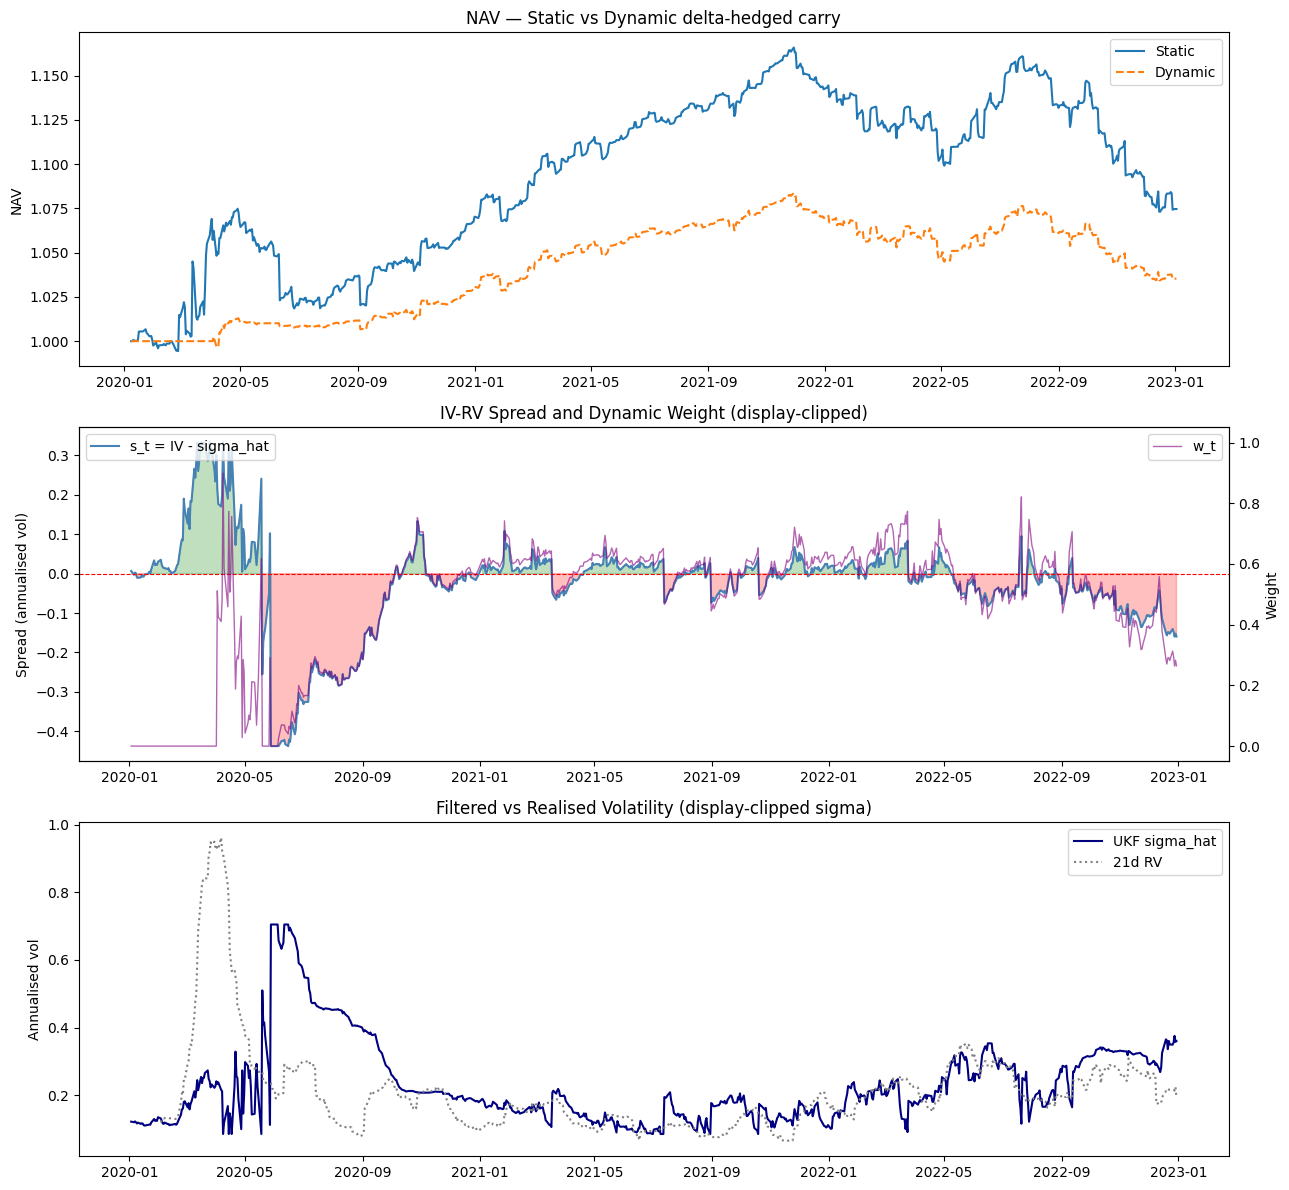

In [9]:
plot_results(
    backtester_static=backtester_static,
    backtester_dynamic=backtester_dynamic,
    spread=spread,
    dynamic_weights=dynamic_weights,
    sigma_filtered=kalman_result["sigma_filtered"],
    log_returns=log_returns,
)